In [ ]:
cd 

### Damian Haviland
### - 12/4/25
***
correlations between average prices, yields, and state by year  
what the mean and medians of yield and colony by state and year  
the trends, on which state has had the most consistent yield and number of colonies over the years

1) Define or measure a specific fact or gather facts about a specific phenomenon. 
2) Match facts and theory.   

Research Questions  

1) Post a problem. 
2) Shape the problem into a testable hypothesis. 
3) Report the results of the tested hypothesis. 

1) What state, by year, has the highest number of colonies and yield per colony?
2) What are the trends in honey in the midwest states (Illinois, Indiana, Iowa, Kansas, Michigan, Minnesota, Missouri, Nebraska, North Dakota, Ohio, South Dakota, and Wisconsin)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import seaborn as sns

In [15]:
# loads and displays the dataset
honey_file = pd.read_csv('US_honey_dataset.xls')
display(honey_file)

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


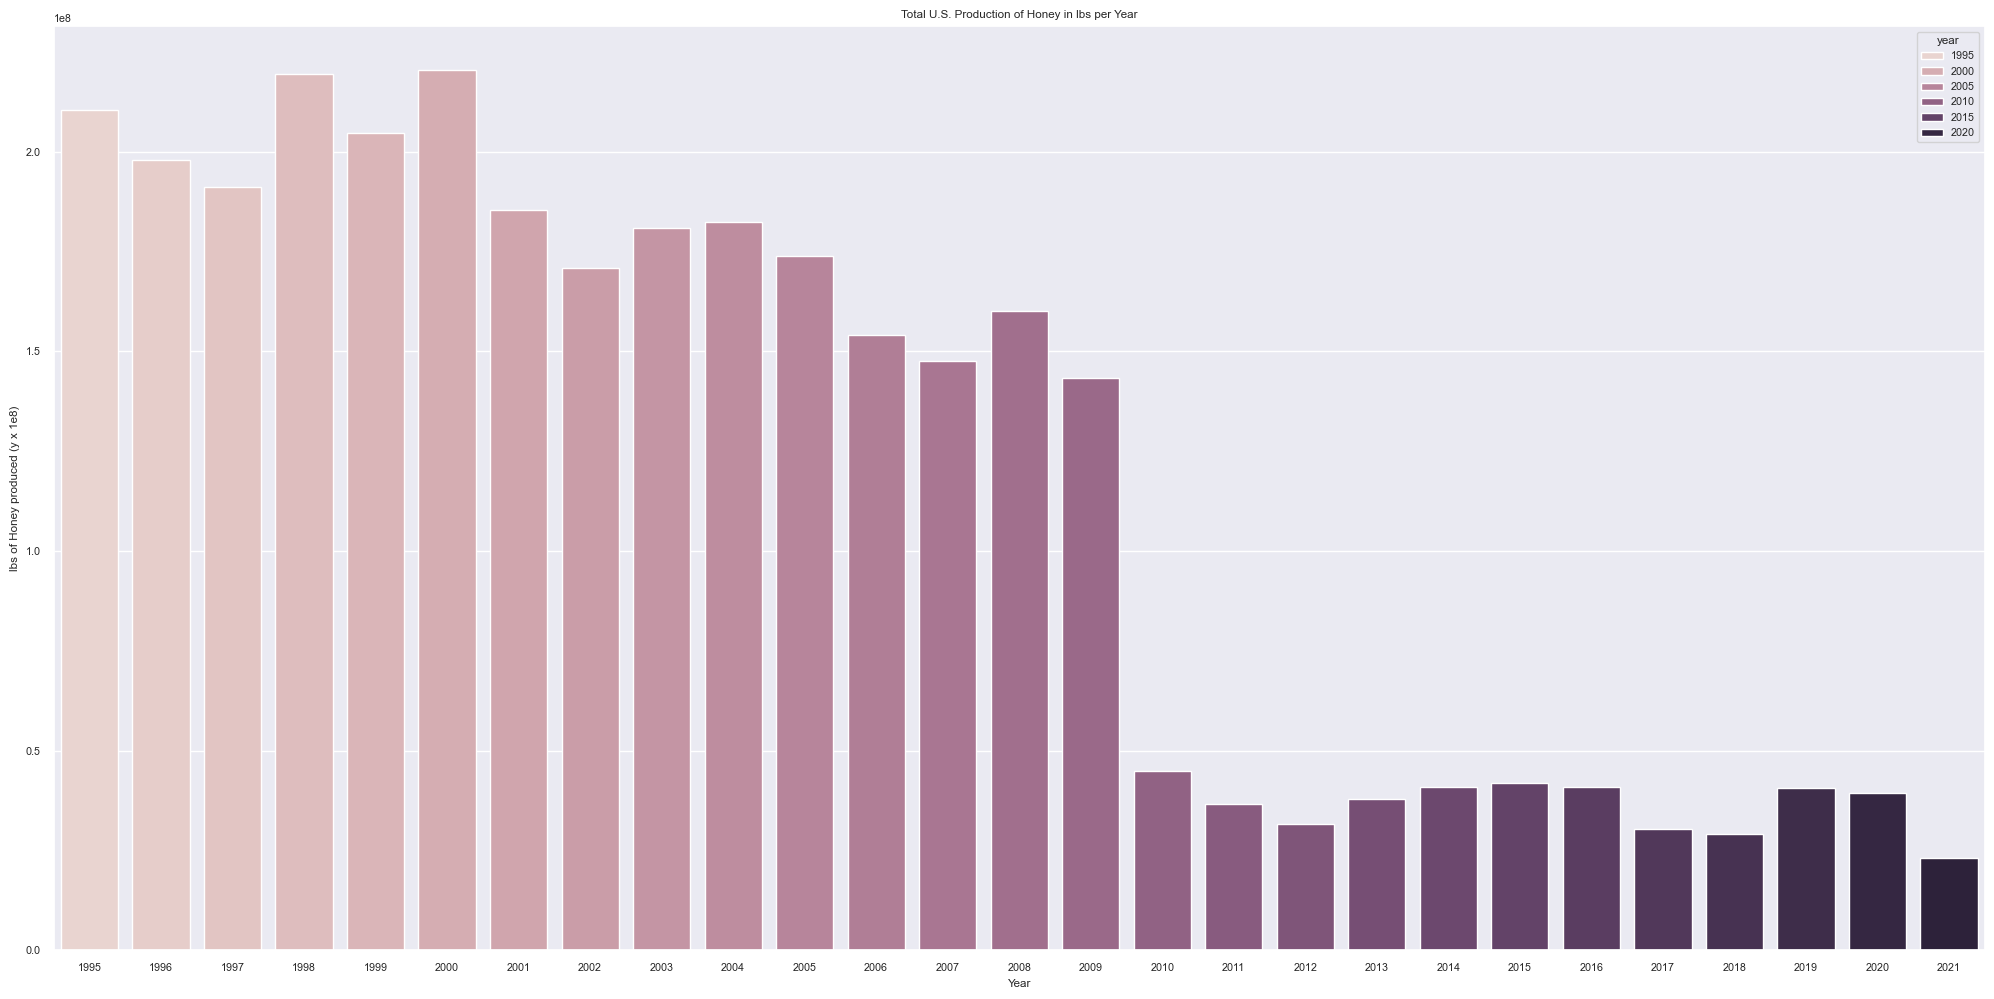

In [198]:
# groups the data by year and then aggregates two sub datasets 
# the sum of the production column by year
# the sum of the number of colonies by year
honey_file_grouped = honey_file.groupby('year').agg(
    total_yield_per_yr = ('production', 'sum'),
    total_colonies_per_yr = ('colonies_number', 'sum')
)
#formats the size of the plot
plt.figure(figsize = (20, 10))

# plots the grouped subset dataset as a bar plot, year (x-value) by total_yield_per_yr (y-value) with hue based on year
totals_by_year = sns.barplot(data = honey_file_grouped, x = 'year', y = 'total_yield_per_yr', hue = 'year')

# formats for tight layout, adds the xlabel 'Year', the ylabel 'lbs of Honey produced (y x 1e8)' with the scale
# formats and adds the title ''Total U.S. Production of Honey in lbs per Year' on the bar plot
plt.tight_layout()
plt.xlabel('Year')
plt.ylabel('lbs of Honey produced (y x 1e8)')
plt.title('Total U.S. Production of Honey in lbs per Year')
plt.show()

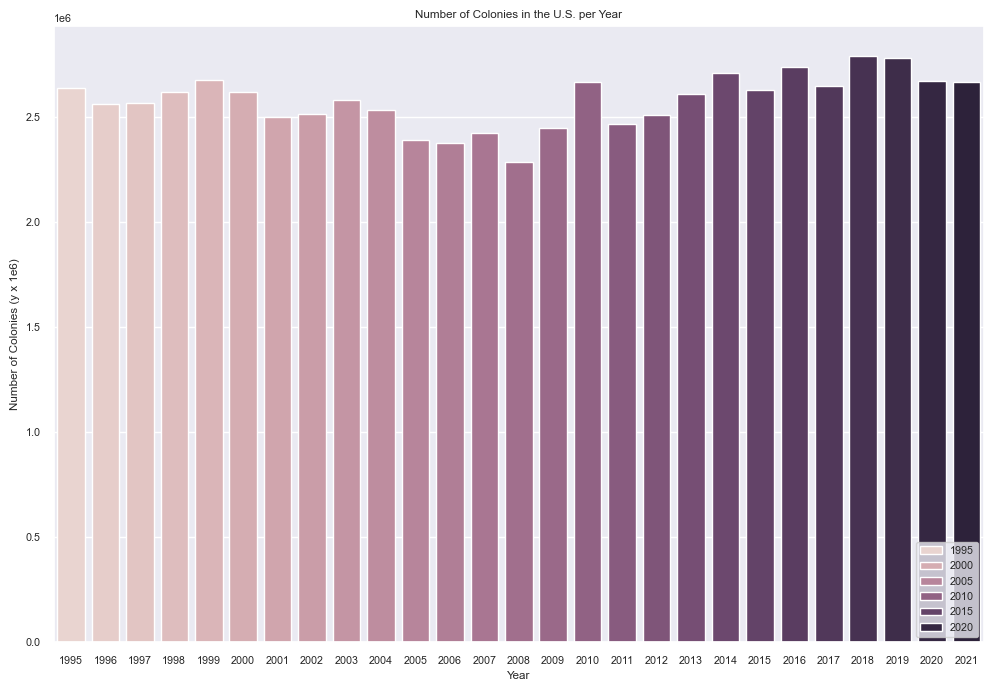

In [199]:
#formats the size of the bar plot 
plt.figure(figsize = (12, 8))

# plots the grouped subset dataset as a bar plot, year (x-value) by total_colonies_per_yr (y-value) with hue based on year
totals_by_year = sns.barplot(data = honey_file_grouped, x = 'year', y = 'total_colonies_per_yr', hue = 'year')

# formats for tight layout, adds the xlabel 'Year', the ylabel 'Total Number of Colonies (y x 1e6)' with the scale
# formats and adds the title 'Total Number of Colonies in the U.S. per Year' on the bar plot
# formats the legend to be in the lower right for readability
plt.xlabel('Year')
plt.ylabel('Total Number of Colonies (y x 1e6)')
plt.title('Number of Colonies in the U.S. per Year')
plt.legend(loc ='lower right')

,avg_yield_midwest,avg_yield_southern,avg_yield_eastern,avg_yield_western
year,,,,
1995,76.666667,66.466667,52.8,63.583333
1996,76.666667,69.866667,55.4,69.833333
1997,73.083333,69.214286,47.8,73.333333
1998,81.583333,66.000000,57.0,68.333333
1999,78.833333,63.571429,52.4,59.750000
2000,81.583333,65.214286,48.0,64.333333
2001,68.916667,69.285714,52.4,62.083333
2002,70.333333,69.066667,64.0,63.333333
2003,66.666667,59.600000,51.4,66.666667


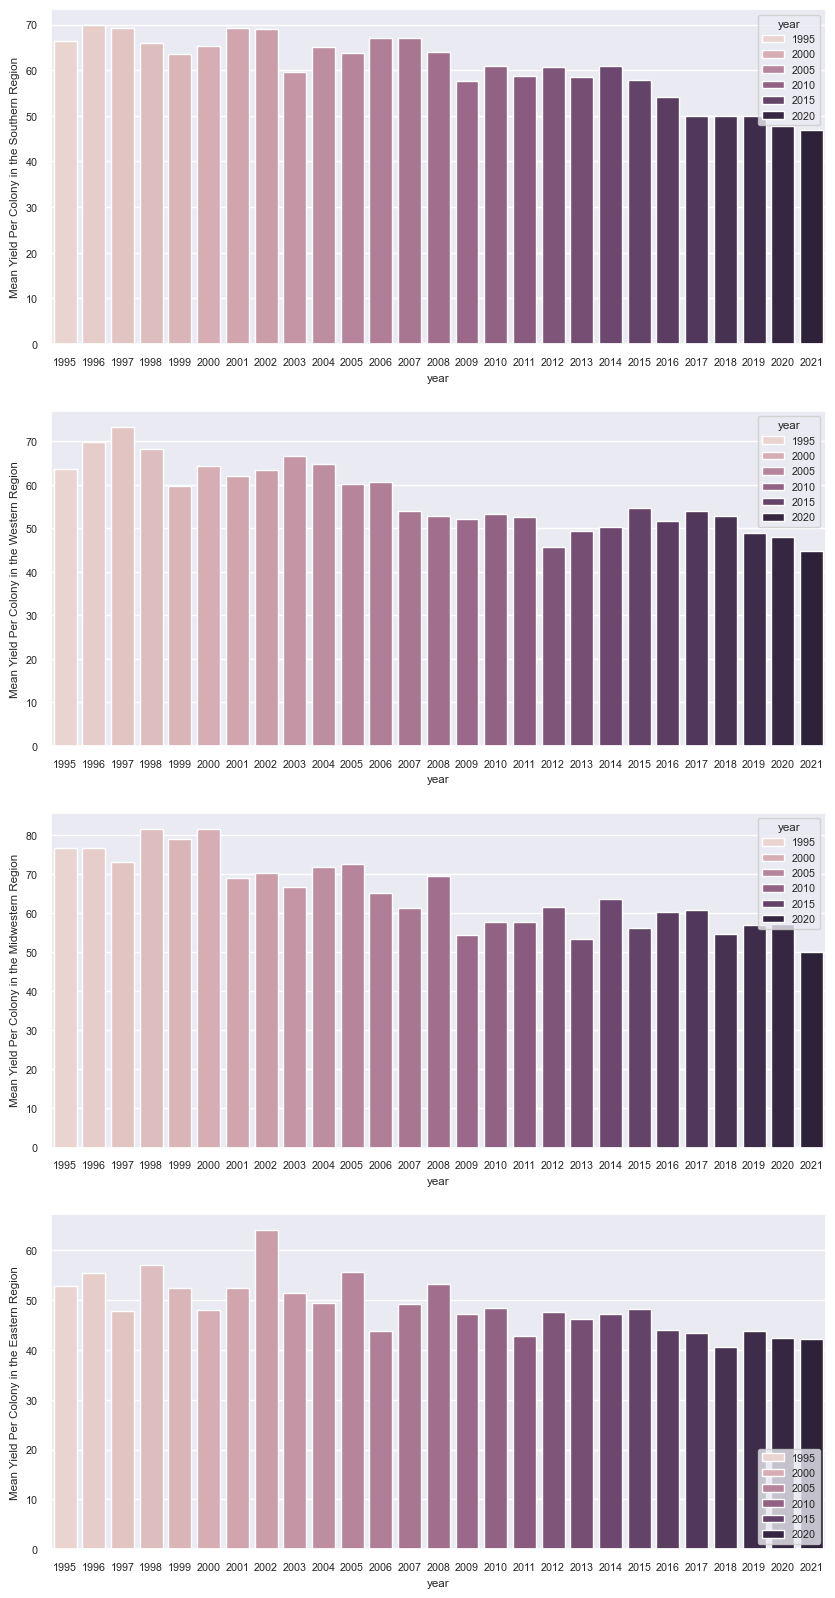

In [206]:
# midwestern states according to wikipedia
midwest_states = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 
                  'Nebraska', 'NorthDakota', 'Ohio', 'SouthDakota', 'Wisconsin']

# eastern states according to wikipedia
east_states = ['Maine', 'NewHampshire', 'Vermont', 'Massachusetts', 'RhodeIsland', 'Connecticut', 'NewJersey', 'NewYork', 'Pennsylvania']

# western states according to wikipedia
western_states = ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 'Nevada', 'NewMexico', 'Oregon', 'Utah', 'Washington', 'Wyoming']

# southern states according to wikipedia
southern_states = ['Alabama', 'Arkansas', 'Delaware', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'NorthCarolina', 'Oklahoma', 
                   'SouthCarolina', 'Tennessee', 'Texas', 'Virginia', 'WestVirginia']

# selects states in the midwest, sorts the data and the aggregates by year for the average yield (lbs) per colony
midwest_states_honey = honey_file[honey_file['state'].isin(midwest_states)]
sorted_midwest_states_honey = midwest_states_honey.sort_values(by = ['state', 'year'])
mean_sorted_midwest_states_honey = sorted_midwest_states_honey.groupby('year').agg(
    avg_yield_midwest = ('yield_per_colony', 'mean')
)

# selects states in the west, sorts the data and the aggregates by year for the average yield (lbs) per colony
west_states_honey = honey_file[honey_file['state'].isin(western_states)]
sorted_west_states_honey = west_states_honey.sort_values(by = ['state', 'year'])
mean_sorted_west_states_honey = sorted_west_states_honey.groupby('year').agg(
    avg_yield_western = ('yield_per_colony', 'mean')
)

# selects states in the east, sorts the data and the aggregates by year for the average yield (lbs) per colony
east_states_honey = honey_file[honey_file['state'].isin(east_states)]
sorted_east_states_honey = east_states_honey.sort_values(by = ['state', 'year'])
mean_sorted_east_states_honey = sorted_east_states_honey.groupby('year').agg(
    avg_yield_eastern = ('yield_per_colony', 'mean')
)

# selects states in the south, sorts the data and the aggregates by year for the average yield (lbs) per colony
southern_states_honey = honey_file[honey_file['state'].isin(southern_states)]
sorted_southern_states_honey = southern_states_honey.sort_values(by = ['state', 'year'])
mean_sorted_southern_states_honey = sorted_southern_states_honey.groupby('year').agg(
    avg_yield_southern = ('yield_per_colony', 'mean')
)
# merges the seperate regional data into one regional dataset using year
merged_regional_data = pd.merge(mean_sorted_midwest_states_honey, mean_sorted_southern_states_honey, on ='year', how ='inner')
merged_regional_data = pd.merge(merged_regional_data, mean_sorted_east_states_honey, on = 'year', how = 'inner')
merged_regional_data = pd.merge(merged_regional_data, mean_sorted_west_states_honey, on = 'year', how = 'inner')

#displays the merged regional dataset
display(merged_regional_data)

# subplot 4 tall x 1 deep
fig, axes = plt.subplots(4, 1)

# plots bar plot for each region, mean yield (y - value) by year (x - value) 
southern_by_year = sns.barplot(data = merged_regional_data, x = 'year', y = 'avg_yield_southern', hue = 'year', ax = axes[0])
western_by_year = sns.barplot(data = merged_regional_data, x = 'year', y = 'avg_yield_western', hue = 'year', ax = axes[1])
midwestern_by_year = sns.barplot(data = merged_regional_data, x = 'year', y = 'avg_yield_midwest', hue = 'year', ax = axes[2])
eastern_by_year = sns.barplot(data = merged_regional_data, x = 'year', y = 'avg_yield_eastern', hue = 'year', ax = axes[3])

# sets y axis label to mean yield per colony in the region
axes[0].set_ylabel('Mean Yield Per Colony in the Southern Region')
axes[1].set_ylabel('Mean Yield Per Colony in the Western Region')
axes[2].set_ylabel('Mean Yield Per Colony in the Midwestern Region')
axes[3].set_ylabel('Mean Yield Per Colony in the Eastern Region')
# formats placement of legend to the lower right
plt.legend(loc ='lower right')
plt.show()
